<a href="https://colab.research.google.com/github/Moustapha72/cv-instagram-filters/blob/main/FinalProjectUpdated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================================
# CELL 1: IMPORT LIBRARIES
# =========================================================

import cv2   #openCV for image processing
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from ipywidgets import Dropdown, IntSlider, FloatSlider, VBox, HBox, Output, Layout
from IPython.display import display, clear_output
from PIL import Image
import io

In [ ]:
# =========================================================
# CELL 2: HELPER FUNCTIONS
# =========================================================

def read_uploaded_image():
    """
    Upload an image from your computer and convert it to RGB.
    Returns:
        filename -> uploaded file name
        image_np -> image as NumPy array
    """
    uploaded = files.upload()

    if not uploaded:
        raise ValueError("No file uploaded.")

    filename = next(iter(uploaded))
    image_bytes = uploaded[filename]

    # Open image and force RGB format
    image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
    image_np = np.array(image)

    return filename, image_np


def show_images(original, result, title_result="Filtered Image"):
    """
    Show original and result side by side.
    """
    plt.figure(figsize=(14, 7))

    # Original image
    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    # Result image
    plt.subplot(1, 2, 2)
    if result.ndim == 2:
        plt.imshow(result, cmap="gray")
    else:
        plt.imshow(result)
    plt.title(title_result)
    plt.axis("off")

    plt.tight_layout()
    plt.show()


def save_image(result, filename="filtered_output.png"):
    """
    Save result image to Colab.
    """
    img_to_save = Image.fromarray(result.astype(np.uint8))
    img_to_save.save(filename)
    print(f"Saved as: {filename}")


def ensure_odd(value):
    """
    Some filters need odd kernel sizes like 3, 5, 7, 9...
    If the value is even, add 1.
    """
    return value if value % 2 == 1 else value + 1


def resize_for_preview(image, scale_percent):
    """
    Resize image for preview only.
    100 = original size
    50 = half size
    150 = bigger
    """
    if scale_percent == 100:
        return image

    width = int(image.shape[1] * scale_percent / 100)
    height = int(image.shape[0] * scale_percent / 100)

    width = max(1, width)
    height = max(1, height)

    resized = cv2.resize(image, (width, height), interpolation=cv2.INTER_AREA)
    return resized

In [ ]:
# =========================================================
# CELL 3: FILTER FUNCTIONS
# =========================================================

def gaussian_blur_filter(image, ksize=9, sigma=2.0):
    """
    Gaussian blur (linear filter).
    ksize = size of filter window
    sigma = amount of smoothing
    """
    ksize = ensure_odd(ksize)
    return cv2.GaussianBlur(image, (ksize, ksize), sigmaX=sigma, sigmaY=sigma)


def sharpen_filter(image, amount=2.0, blur_ksize=9, sigma=2.0):
    """
    Sharpen using unsharp masking:
    1. Blur image
    2. Subtract blur from original
    3. This boosts edges/details
    """
    blur_ksize = ensure_odd(blur_ksize)
    blurred = cv2.GaussianBlur(image, (blur_ksize, blur_ksize), sigma)

    sharpened = cv2.addWeighted(image, 1 + amount, blurred, -amount, 0)
    return np.clip(sharpened, 0, 255).astype(np.uint8)


def emboss_filter(image, strength=1.0):
    """
    Emboss using a custom 2D convolution kernel.
    This directly satisfies the project's custom kernel requirement.
    """
    kernel = np.array([
        [-2, -1,  0],
        [-1,  1,  1],
        [ 0,  1,  2]
    ], dtype=np.float32) * strength

    result = cv2.filter2D(image, -1, kernel)

    # Shift values toward visible gray
    result = np.clip(result + 128, 0, 255).astype(np.uint8)
    return result


def median_filter(image, ksize=5):
    """
    Median filter (non-linear).
    Good for impulse noise / salt-and-pepper noise.

    instead of averaging,, it picks the middle value, which helps keep edges better than normal blur
    """
    ksize = ensure_odd(ksize)
    return cv2.medianBlur(image, ksize)


def bilateral_filter_custom(image, d=9, sigma_color=75, sigma_space=75):
    """
    Bilateral filter (non-linear, edge-preserving).

    this smooths image but tries to keep edges

    d = neighbourhood size
    sigma color = how much color difference is allowed
    sigma space = how much distance matters
    """
    return cv2.bilateralFilter(image, d, sigma_color, sigma_space)


def sepia_filter(image, intensity=1.0):
    """
    Sepia tone as a colour transformation, old bphoto pbrown effect


    intensity = 0 means original
    intensity = 1 means full sepia
    """
    img = image.astype(np.float32)

    sepia_matrix = np.array([
        [0.393, 0.769, 0.189],
        [0.349, 0.686, 0.168],
        [0.272, 0.534, 0.131]
    ], dtype=np.float32)

    sepia = img @ sepia_matrix.T
    sepia = np.clip(sepia, 0, 255)

    blended = cv2.addWeighted(img, 1 - intensity, sepia, intensity, 0)
    return np.clip(blended, 0, 255).astype(np.uint8)


def grayscale_filter(image):
    """
    Convert RGB image to grayscale.
    """
    return cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)


def vignette_filter(image, sigma_scale=0.35, strength=1.0):
    """
    Vignette = darker edges, brighter center.

    sigma_scale controls spread of bright center.
    strength controls how strong the effect is.
    """
    rows, cols = image.shape[:2]

    sigma_x = max(1, cols * sigma_scale)
    sigma_y = max(1, rows * sigma_scale)

    kernel_x = cv2.getGaussianKernel(cols, sigma_x)
    kernel_y = cv2.getGaussianKernel(rows, sigma_y)
    mask = kernel_y @ kernel_x.T
    mask = mask / mask.max()

    # Blend between no vignette and full vignette
    mask = (1 - strength) + strength * mask

    if image.ndim == 3:
        output = np.zeros_like(image, dtype=np.float32)
        for c in range(3):
            output[:, :, c] = image[:, :, c] * mask
    else:
        output = image * mask

    return np.clip(output, 0, 255).astype(np.uint8)


def pencil_sketch_filter(image, blur_ksize=21, sigma=0):
    """
    Pencil sketch effect:
    1. Convert to grayscale
    2. Invert
    3. Gaussian blur
    4. Invert blur
    5. Divide original gray by inverted blur

    This is easy to explain using edge and smoothing concepts.
    """
    blur_ksize = ensure_odd(blur_ksize)

    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    inverted = 255 - gray
    blurred = cv2.GaussianBlur(inverted, (blur_ksize, blur_ksize), sigma)
    inverted_blur = 255 - blurred
    sketch = cv2.divide(gray, inverted_blur, scale=256.0)


    return sketch

def box_blur_filter(image, ksize=9):
    """
    Box blur / mean filter.
    This is a linear filter using a custom averaging kernel.
    """
    ksize = ensure_odd(ksize)

    # Create a ksize x ksize averaging kernel
    kernel = np.ones((ksize, ksize), dtype=np.float32) / (ksize * ksize)

    # Apply 2D convolution using OpenCV
    return cv2.filter2D(image, -1, kernel)


def sobel_edge_filter(image, ksize=3):
    """
    Sobel edge detector.
    Computes image gradients in x and y directions, then combines them.

    """
    ksize = ensure_odd(ksize)

    # Convert to grayscale first because edge detectors usually work on intensity
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Sobel gradient in x and y
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=ksize)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=ksize)

    # Gradient magnitude
    magnitude = np.sqrt(gx**2 + gy**2)

    # Normalize to [0,255] so it displays nicely
    magnitude = np.clip(magnitude, 0, 255).astype(np.uint8)

    return magnitude


def laplacian_edge_filter(image, ksize=3):
    """
    Laplacian edge detector.
    Uses second derivative to highlight rapid intensity changes, basically to find strong intensity changes
    """
    ksize = ensure_odd(ksize)

    # Convert to grayscale first
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Apply Laplacian
    lap = cv2.Laplacian(gray, cv2.CV_64F, ksize=ksize)

    # Take absolute value so edges show clearly
    lap = np.abs(lap)

    # Normalize to display range
    lap = np.clip(lap, 0, 255).astype(np.uint8)

    return lap

In [ ]:
# =========================================================
# CELL 4: MAIN FILTER SELECTOR
# =========================================================

def apply_filter(
    image,
    filter_name,
    gaussian_ksize=9,
    gaussian_sigma=2.0,
    sharpen_amount=2.0,
    sharpen_blur_ksize=9,
    sharpen_sigma=2.0,
    median_ksize=5,
    bilateral_d=9,
    bilateral_sigma_color=75,
    bilateral_sigma_space=75,
    emboss_strength=1.0,
    sepia_intensity=1.0,
    vignette_sigma_scale=0.35,
    vignette_strength=1.0,
    sketch_blur_ksize=21,
    sketch_sigma=0,
    box_blur_ksize=9,
    sobel_ksize=3,
    laplacian_ksize=3
):
    """
    Choose which filter to apply.
    """

    if filter_name == "Gaussian Blur":
        return gaussian_blur_filter(image, gaussian_ksize, gaussian_sigma)

    elif filter_name == "Box Blur":
        return box_blur_filter(image, box_blur_ksize)

    elif filter_name == "Sharpen":
        return sharpen_filter(image, sharpen_amount, sharpen_blur_ksize, sharpen_sigma)

    elif filter_name == "Emboss":
        return emboss_filter(image, emboss_strength)

    elif filter_name == "Median":
        return median_filter(image, median_ksize)

    elif filter_name == "Bilateral":
        return bilateral_filter_custom(image, bilateral_d, bilateral_sigma_color, bilateral_sigma_space)

    elif filter_name == "Sepia":
        return sepia_filter(image, sepia_intensity)

    elif filter_name == "Grayscale":
        return grayscale_filter(image)

    elif filter_name == "Vignette":
        return vignette_filter(image, vignette_sigma_scale, vignette_strength)

    elif filter_name == "Pencil Sketch":
        return pencil_sketch_filter(image, sketch_blur_ksize, sketch_sigma)

    elif filter_name == "Sobel Edge":
        return sobel_edge_filter(image, sobel_ksize)

    elif filter_name == "Laplacian Edge":
        return laplacian_edge_filter(image, laplacian_ksize)

    else:
        return image

Saving car.avif to car.avif
Loaded file: car.avif


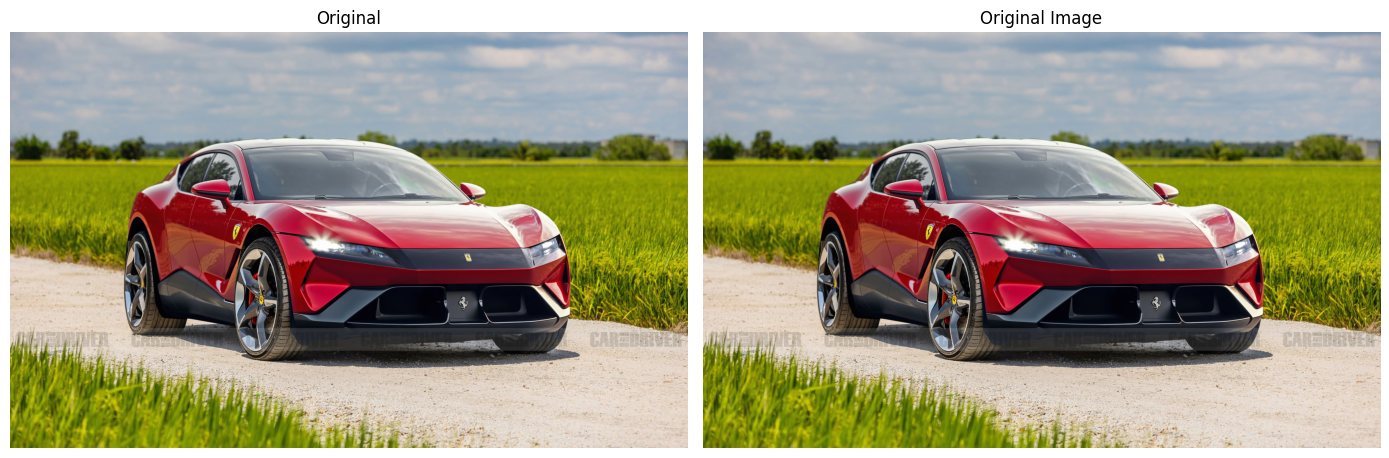

In [ ]:
# =========================================================
# CELL 5: UPLOAD IMAGE
# =========================================================

filename, original_img = read_uploaded_image()
print(f"Loaded file: {filename}")

show_images(original_img, original_img, "Original Image")

In [ ]:
# =========================================================
# CELL 6: INTERACTIVE UI
# =========================================================

# -----------------------------
# FILTER CHOICE
# -----------------------------
filter_dropdown = Dropdown(
    options=[
        "Gaussian Blur",
        "Box Blur",
        "Sharpen",
        "Emboss",
        "Median",
        "Bilateral",
        "Sepia",
        "Grayscale",
        "Vignette",
        "Pencil Sketch",
        "Sobel Edge",
        "Laplacian Edge"
    ],
    value="Gaussian Blur",
    description="Filter:",
    layout=Layout(width="300px")
)


# -----------------------------
# PREVIEW SCALE
# -----------------------------
preview_scale_slider = IntSlider(
    value=100, min=25, max=150, step=25,
    description="Preview %",
    layout=Layout(width="350px")
)

# -----------------------------
# GAUSSIAN BLUR CONTROLS
# -----------------------------
gaussian_ksize_slider = IntSlider(
    value=9, min=3, max=31, step=2,
    description="Blur KSize",
    layout=Layout(width="350px")
)

gaussian_sigma_slider = FloatSlider(
    value=2.0, min=0.1, max=10.0, step=0.1,
    description="Blur Sigma",
    layout=Layout(width="350px")
)

# -----------------------------
# SHARPEN CONTROLS
# -----------------------------
sharpen_amount_slider = FloatSlider(
    value=2.0, min=0.1, max=5.0, step=0.1,
    description="Sharp Amt",
    layout=Layout(width="350px")
)

sharpen_blur_ksize_slider = IntSlider(
    value=9, min=3, max=31, step=2,
    description="Sharp KSize",
    layout=Layout(width="350px")
)

sharpen_sigma_slider = FloatSlider(
    value=2.0, min=0.1, max=10.0, step=0.1,
    description="Sharp Sigma",
    layout=Layout(width="350px")
)

# -----------------------------
# EMBOSS CONTROLS
# -----------------------------
emboss_strength_slider = FloatSlider(
    value=1.0, min=0.1, max=4.0, step=0.1,
    description="Emboss Str",
    layout=Layout(width="350px")
)

# -----------------------------
# MEDIAN CONTROLS
# -----------------------------
median_ksize_slider = IntSlider(
    value=5, min=3, max=21, step=2,
    description="Median KSize",
    layout=Layout(width="350px")
)

# -----------------------------
# BILATERAL CONTROLS
# -----------------------------
bilateral_d_slider = IntSlider(
    value=9, min=1, max=25, step=2,
    description="Bilateral d",
    layout=Layout(width="350px")
)

bilateral_sigma_color_slider = IntSlider(
    value=75, min=1, max=200, step=1,
    description="Sigma Color",
    layout=Layout(width="350px")
)

bilateral_sigma_space_slider = IntSlider(
    value=75, min=1, max=200, step=1,
    description="Sigma Space",
    layout=Layout(width="350px")
)

# -----------------------------
# SEPIA CONTROLS
# -----------------------------
sepia_intensity_slider = FloatSlider(
    value=1.0, min=0.0, max=1.0, step=0.05,
    description="Sepia Int",
    layout=Layout(width="350px")
)

# -----------------------------
# VIGNETTE CONTROLS
# -----------------------------
vignette_sigma_scale_slider = FloatSlider(
    value=0.35, min=0.05, max=1.0, step=0.01,
    description="Vig Sigma",
    layout=Layout(width="350px")
)

vignette_strength_slider = FloatSlider(
    value=1.0, min=0.0, max=1.0, step=0.05,
    description="Vig Strength",
    layout=Layout(width="350px")
)

# -----------------------------
# PENCIL SKETCH CONTROLS
# -----------------------------
sketch_blur_ksize_slider = IntSlider(
    value=21, min=3, max=41, step=2,
    description="Sketch KSize",
    layout=Layout(width="350px")
)

sketch_sigma_slider = FloatSlider(
    value=0.0, min=0.0, max=10.0, step=0.1,
    description="Sketch Sigma",
    layout=Layout(width="350px")
)

# -----------------------------
# BOX BLUR CONTROLS
# -----------------------------
box_blur_ksize_slider = IntSlider(
    value=9, min=3, max=31, step=2,
    description="Box KSize",
    layout=Layout(width="350px")
)

# -----------------------------
# SOBEL EDGE CONTROLS
# -----------------------------
sobel_ksize_slider = IntSlider(
    value=3, min=3, max=9, step=2,
    description="Sobel KSize",
    layout=Layout(width="350px")
)

# -----------------------------
# LAPLACIAN EDGE CONTROLS
# -----------------------------
laplacian_ksize_slider = IntSlider(
    value=3, min=3, max=9, step=2,
    description="Lap KSize",
    layout=Layout(width="350px")
)

# Output box
output = Output()


def update_filter(change=None):
    """
    Run whenever a slider/dropdown changes.
    """
    with output:
        clear_output(wait=True)

        # Resize preview only
        preview_img = resize_for_preview(original_img, preview_scale_slider.value)

        result = apply_filter(
            preview_img,
            filter_dropdown.value,
            gaussian_ksize=gaussian_ksize_slider.value,
            gaussian_sigma=gaussian_sigma_slider.value,
            sharpen_amount=sharpen_amount_slider.value,
            sharpen_blur_ksize=sharpen_blur_ksize_slider.value,
            sharpen_sigma=sharpen_sigma_slider.value,
            median_ksize=median_ksize_slider.value,
            bilateral_d=bilateral_d_slider.value,
            bilateral_sigma_color=bilateral_sigma_color_slider.value,
            bilateral_sigma_space=bilateral_sigma_space_slider.value,
            emboss_strength=emboss_strength_slider.value,
            sepia_intensity=sepia_intensity_slider.value,
            vignette_sigma_scale=vignette_sigma_scale_slider.value,
            vignette_strength=vignette_strength_slider.value,
            sketch_blur_ksize=sketch_blur_ksize_slider.value,
            sketch_sigma=sketch_sigma_slider.value,
            box_blur_ksize=box_blur_ksize_slider.value,
            sobel_ksize=sobel_ksize_slider.value,
            laplacian_ksize=laplacian_ksize_slider.value
        )

        show_images(preview_img, result, filter_dropdown.value)

        print("Current settings:")
        print(f"Filter = {filter_dropdown.value}")
        print(f"Preview Scale = {preview_scale_slider.value}%")
        print(f"Gaussian Blur: ksize={gaussian_ksize_slider.value}, sigma={gaussian_sigma_slider.value}")
        print(f"Sharpen: amount={sharpen_amount_slider.value}, blur_ksize={sharpen_blur_ksize_slider.value}, sigma={sharpen_sigma_slider.value}")
        print(f"Emboss: strength={emboss_strength_slider.value}")
        print(f"Median: ksize={median_ksize_slider.value}")
        print(f"Bilateral: d={bilateral_d_slider.value}, sigmaColor={bilateral_sigma_color_slider.value}, sigmaSpace={bilateral_sigma_space_slider.value}")
        print(f"Sepia: intensity={sepia_intensity_slider.value}")
        print(f"Vignette: sigma_scale={vignette_sigma_scale_slider.value}, strength={vignette_strength_slider.value}")
        print(f"Pencil Sketch: blur_ksize={sketch_blur_ksize_slider.value}, sigma={sketch_sigma_slider.value}")
        print(f"Box Blur: ksize={box_blur_ksize_slider.value}")
        print(f"Sobel: ksize={sobel_ksize_slider.value}")
        print(f"Laplacian: ksize={laplacian_ksize_slider.value}")


widgets_list = [
    filter_dropdown,
    preview_scale_slider,
    gaussian_ksize_slider, gaussian_sigma_slider,
    box_blur_ksize_slider,
    sharpen_amount_slider, sharpen_blur_ksize_slider, sharpen_sigma_slider,
    emboss_strength_slider,
    median_ksize_slider,
    bilateral_d_slider, bilateral_sigma_color_slider, bilateral_sigma_space_slider,
    sepia_intensity_slider,
    vignette_sigma_scale_slider, vignette_strength_slider,
    sketch_blur_ksize_slider, sketch_sigma_slider,
    sobel_ksize_slider,
    laplacian_ksize_slider
]

for w in widgets_list:
    w.observe(update_filter, names="value")

controls_left = VBox([
    filter_dropdown,
    preview_scale_slider,
    gaussian_ksize_slider,
    gaussian_sigma_slider,
    box_blur_ksize_slider,
    sharpen_amount_slider,
    sharpen_blur_ksize_slider,
    sharpen_sigma_slider,
    emboss_strength_slider
])

controls_right = VBox([
    median_ksize_slider,
    bilateral_d_slider,
    bilateral_sigma_color_slider,
    bilateral_sigma_space_slider,
    sepia_intensity_slider,
    vignette_sigma_scale_slider,
    vignette_strength_slider,
    sketch_blur_ksize_slider,
    sketch_sigma_slider,
    sobel_ksize_slider,
    laplacian_ksize_slider
])

display(HBox([controls_left, controls_right]))
display(output)

update_filter()

Output()

In [ ]:
# =========================================================
# CELL 7: SAVE FULL-RESOLUTION RESULT
# =========================================================

# IMPORTANT:
# This saves using the ORIGINAL image, not the resized preview image.

final_result = apply_filter(
    original_img,
    filter_dropdown.value,
    gaussian_ksize=gaussian_ksize_slider.value,
    gaussian_sigma=gaussian_sigma_slider.value,
    sharpen_amount=sharpen_amount_slider.value,
    sharpen_blur_ksize=sharpen_blur_ksize_slider.value,
    sharpen_sigma=sharpen_sigma_slider.value,
    median_ksize=median_ksize_slider.value,
    bilateral_d=bilateral_d_slider.value,
    bilateral_sigma_color=bilateral_sigma_color_slider.value,
    bilateral_sigma_space=bilateral_sigma_space_slider.value,
    emboss_strength=emboss_strength_slider.value,
    sepia_intensity=sepia_intensity_slider.value,
    vignette_sigma_scale=vignette_sigma_scale_slider.value,
    vignette_strength=vignette_strength_slider.value,
    sketch_blur_ksize=sketch_blur_ksize_slider.value,
    sketch_sigma=sketch_sigma_slider.value,
    box_blur_ksize=box_blur_ksize_slider.value,
    sobel_ksize=sobel_ksize_slider.value,
    laplacian_ksize=laplacian_ksize_slider.value
)

save_name = f"{filter_dropdown.value.lower().replace(' ', '_')}_output.png"
save_image(final_result, save_name)

# Download to your computer
files.download(save_name)

Saved as: gaussian_blur_output.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>